In [3]:
# Parte 1 – Pré-processamento e Organização das Imagens Médicas
## **Dataset:** MedMNIST – BloodMNIST (células do sangue, 8 classes)

## Este notebook cobre:
## - Download e exploração do dataset
## - Redimensionamento, normalização e conversão de formatos
## - Criação dos conjuntos de treino, validação e teste
## - Visualizações e estatísticas do pipeline

In [4]:
# Instalação das bibliotecas necessárias
!pip install medmnist Pillow numpy matplotlib scikit-learn torchvision torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.2 MB/s eta 0:00:00


In [5]:
## 2. Importar bibliotecas
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import medmnist
from medmnist import BloodMNIST, INFO
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import torch
from sklearn.model_selection import train_test_split

print(f'MedMNIST versão: {medmnist.__version__}')
print(f'PyTorch versão: {torch.__version__}')

MedMNIST versão: 3.0.2
PyTorch versão: 2.11.0+cpu


In [6]:
## 3. Informações sobre o Dataset BloodMNIST
# Exibe metadados do BloodMNIST
info = INFO['bloodmnist']
print('=== Informações do BloodMNIST ===')
print(f"Descrição: {info['description']}")
print(f"Número de classes: {info['n_channels']} canais, {len(info['label'])} classes")
print(f"Tamanho original das imagens: {info['n_channels']} canais")
print(f"\nClasses:")
for idx, label in info['label'].items():
    print(f"  {idx}: {label}")

=== Informações do BloodMNIST ===
Descrição: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
Número de classes: 3 canais, 8 classes
Tamanho original das imagens: 3 canais

Classes:
  0: basophil
  1: eosinophil
  2: erythroblast
  3: immature granulocytes(myelocytes, metamyelocytes and promyelocytes)
  4: lymphocyte
  5: monocyte
  6: neutrophil
  7: platelet


In [7]:
## 4. Download e Carregamento do Dataset
# ─── Parâmetros do Pipeline ───────────────────────────────
TAMANHO_IMAGEM = 64      # Redimensionamento para 64x64 pixels
BATCH_SIZE     = 32      # Tamanho do batch para DataLoader
SEED           = 42      # Semente para reprodutibilidade
DATA_DIR       = './data'

torch.manual_seed(SEED)
np.random.seed(SEED)
os.makedirs(DATA_DIR, exist_ok=True)

# Download do dataset SEM transformações (para exploração bruta)
dataset_raw_treino = BloodMNIST(split='train', download=True, root=DATA_DIR, size=28)
dataset_raw_val    = BloodMNIST(split='val',   download=True, root=DATA_DIR, size=28)
dataset_raw_teste  = BloodMNIST(split='test',  download=True, root=DATA_DIR, size=28)

print(f'\nTamanhos dos splits originais:')
print(f'  Treino : {len(dataset_raw_treino)} amostras')
print(f'  Val    : {len(dataset_raw_val)} amostras')
print(f'  Teste  : {len(dataset_raw_teste)} amostras')
print(f'  TOTAL  : {len(dataset_raw_treino) + len(dataset_raw_val) + len(dataset_raw_teste)} amostras')

100%|██████████| 35.5M/35.5M [00:01<00:00, 19.6MB/s]



Tamanhos dos splits originais:
  Treino : 11959 amostras
  Val    : 1712 amostras
  Teste  : 3421 amostras
  TOTAL  : 17092 amostras


/tmp/ipykernel_7226/3090308503.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lbl = int(label)


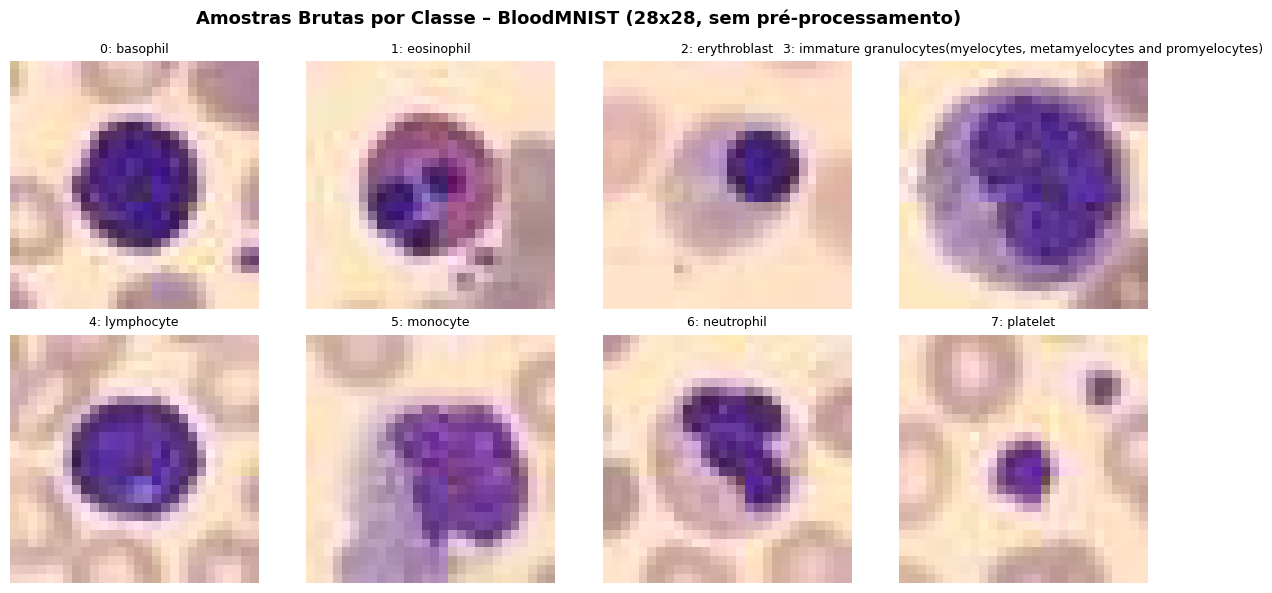

Figura salva como amostras_brutas.png


In [8]:
## 5. Exploração Visual – Amostras Brutas (Pré-processamento)
# Visualiza amostras brutas antes de qualquer pré-processamento
info   = INFO['bloodmnist']
labels = info['label']

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Amostras Brutas por Classe – BloodMNIST (28x28, sem pré-processamento)',
             fontsize=13, fontweight='bold')

mostrados = set()
for img, label in dataset_raw_treino:
    lbl = int(label)
    if lbl not in mostrados:
        ax = axes[lbl // 4][lbl % 4]
        ax.imshow(img)
        ax.set_title(f'{lbl}: {labels[str(lbl)]}', fontsize=9)
        ax.axis('off')
        mostrados.add(lbl)
    if len(mostrados) == 8:
        break

plt.tight_layout()
plt.savefig('amostras_brutas.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva como amostras_brutas.png')

In [9]:
## 6. Pipeline de Pré-processamento

##Aplicamos as seguintes transformações:
## 1. **Redimensionamento** para 64×64 pixels
## 2. **Conversão para tensor** PyTorch (valores entre 0 e 1)
## 3. **Normalização** com média e desvio padrão calculados no treino
## 4. **Augmentação** (apenas no treino): flip horizontal e rotação leve

# ─── Passo 6.1: Calcular média e std do conjunto de treino ───
temp_transform = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),
    transforms.ToTensor()
])

dataset_temp = BloodMNIST(split='train', download=False, root=DATA_DIR,
                           size=28, transform=temp_transform)
loader_temp  = DataLoader(dataset_temp, batch_size=512, shuffle=False)

canais_soma  = torch.zeros(3)
canais_soma2 = torch.zeros(3)
n_pixels     = 0

for imgs, _ in loader_temp:
    b, c, h, w  = imgs.shape
    canais_soma  += imgs.sum(dim=[0,2,3])
    canais_soma2 += (imgs**2).sum(dim=[0,2,3])
    n_pixels     += b * h * w

media = canais_soma  / n_pixels
std   = (canais_soma2 / n_pixels - media**2).sqrt()

print('Estatísticas calculadas no conjunto de treino (após resize para 64x64):')
print(f'  Média por canal (R,G,B): {media.numpy().round(4)}')
print(f'  Desvio padrão  (R,G,B): {std.numpy().round(4)}')

Estatísticas calculadas no conjunto de treino (após resize para 64x64):
  Média por canal (R,G,B): [0.7944 0.6597 0.6963]
  Desvio padrão  (R,G,B): [0.2109 0.2369 0.111 ]


In [10]:
# ─── Passo 6.2: Definir transformações finais ────────────────

# Treino: com augmentação
transform_treino = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),          # Redimensionamento
    transforms.RandomHorizontalFlip(p=0.5),                        # Flip aleatório
    transforms.RandomRotation(degrees=15),                         # Rotação leve
    transforms.ToTensor(),                                         # Converte para tensor [0,1]
    transforms.Normalize(mean=media.tolist(), std=std.tolist())    # Normalização Z-score
])

# Validação e Teste: sem augmentação
transform_eval = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),
    transforms.ToTensor(),
    transforms.Normalize(mean=media.tolist(), std=std.tolist())
])

print('Transformações definidas com sucesso!')
print(f'\nTransform TREINO:\n{transform_treino}')
print(f'\nTransform EVAL (val/teste):\n{transform_eval}')

Transformações definidas com sucesso!

Transform TREINO:
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.7944125533103943, 0.6597318649291992, 0.6962726712226868], std=[0.2109019011259079, 0.23692667484283447, 0.11095836013555527])
)

Transform EVAL (val/teste):
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.7944125533103943, 0.6597318649291992, 0.6962726712226868], std=[0.2109019011259079, 0.23692667484283447, 0.11095836013555527])
)


In [11]:
## 7. Criação dos Conjuntos de Treino, Validação e Teste

# Carregando os datasets com as transformações finais
ds_treino = BloodMNIST(split='train', download=False, root=DATA_DIR,
                        size=28, transform=transform_treino)
ds_val    = BloodMNIST(split='val',   download=False, root=DATA_DIR,
                        size=28, transform=transform_eval)
ds_teste  = BloodMNIST(split='test',  download=False, root=DATA_DIR,
                        size=28, transform=transform_eval)

# DataLoaders
loader_treino = DataLoader(ds_treino, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
loader_val    = DataLoader(ds_val,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
loader_teste  = DataLoader(ds_teste,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

total = len(ds_treino) + len(ds_val) + len(ds_teste)
print('=== Divisão dos Conjuntos ===')
print(f'  Treino     : {len(ds_treino):5d} amostras  ({100*len(ds_treino)/total:.1f}%)')
print(f'  Validação  : {len(ds_val):5d} amostras  ({100*len(ds_val)/total:.1f}%)')
print(f'  Teste      : {len(ds_teste):5d} amostras  ({100*len(ds_teste)/total:.1f}%)')
print(f'  Total      : {total:5d} amostras')
print(f'\nShape de um batch: {next(iter(loader_treino))[0].shape}  (B x C x H x W)')

=== Divisão dos Conjuntos ===
  Treino     : 11959 amostras  (70.0%)
  Validação  :  1712 amostras  (10.0%)
  Teste      :  3421 amostras  (20.0%)
  Total      : 17092 amostras

Shape de um batch: torch.Size([32, 3, 64, 64])  (B x C x H x W)


/tmp/ipykernel_7226/4250062089.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  contagem[int(label)] += 1


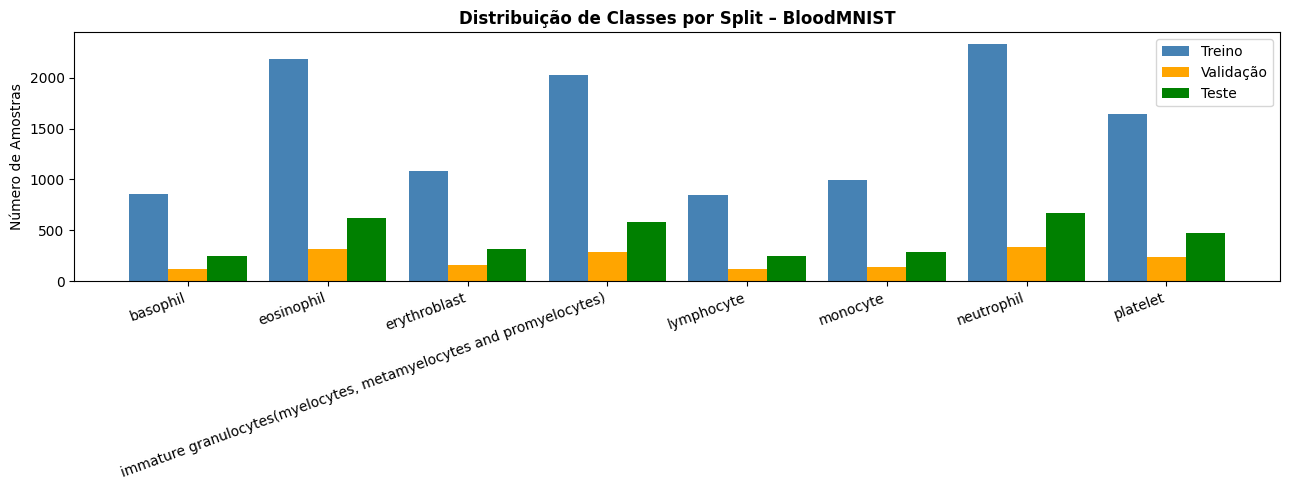

Figura salva como distribuicao_classes.png


In [12]:
## 8. Distribuição de Classes
# Contagem de amostras por classe em cada split
def contar_classes(dataset, n_classes=8):
    contagem = np.zeros(n_classes, dtype=int)
    for _, label in dataset:
        contagem[int(label)] += 1
    return contagem

cont_treino = contar_classes(ds_treino)
cont_val    = contar_classes(ds_val)
cont_teste  = contar_classes(ds_teste)
nomes       = [labels[str(i)] for i in range(8)]

x = np.arange(8)
w = 0.28
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,   cont_treino, w, label='Treino',    color='steelblue')
ax.bar(x,       cont_val,    w, label='Validação', color='orange')
ax.bar(x + w,   cont_teste,  w, label='Teste',     color='green')
ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Número de Amostras')
ax.set_title('Distribuição de Classes por Split – BloodMNIST', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva como distribuicao_classes.png')

/tmp/ipykernel_7226/4063045594.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[0, i].set_title(f'Antes\n28×28\n{labels[str(int(lbl_bruta))]}', fontsize=8)
/tmp/ipykernel_7226/4063045594.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[1, i].set_title(f'Depois\n64×64 norm.\n{labels[str(int(lbl_proc))]}', fontsize=8)


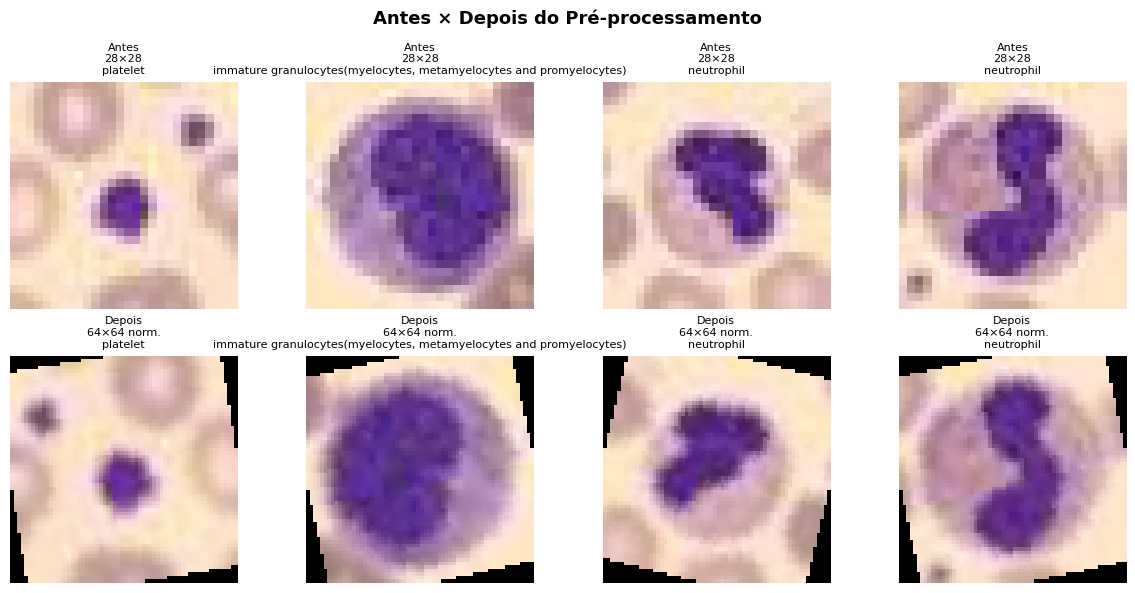

Figura salva como antes_depois.png


In [13]:
## 9. Visualização Antes × Depois do Pré-processamento
# Compara imagens brutas (28x28) vs processadas (64x64, normalizadas)
n_amostras = 4
fig, axes = plt.subplots(2, n_amostras, figsize=(12, 6))
fig.suptitle('Antes × Depois do Pré-processamento', fontsize=13, fontweight='bold')

for i in range(n_amostras):
    img_bruta,  lbl_bruta  = dataset_raw_treino[i]
    img_proc,   lbl_proc   = ds_treino[i]

    # Antes
    axes[0, i].imshow(img_bruta)
    axes[0, i].set_title(f'Antes\n28×28\n{labels[str(int(lbl_bruta))]}', fontsize=8)
    axes[0, i].axis('off')

    # Depois: desnormaliza para visualização
    img_vis = img_proc.permute(1, 2, 0).numpy()
    img_vis = img_vis * std.numpy() + media.numpy()
    img_vis = np.clip(img_vis, 0, 1)
    axes[1, i].imshow(img_vis)
    axes[1, i].set_title(f'Depois\n64×64 norm.\n{labels[str(int(lbl_proc))]}', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('antes_depois.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva como antes_depois.png')

In [14]:
## 10. Salvando Estatísticas do Pipeline
# Salva os parâmetros de normalização para uso futuro (Parte 2)
import json

pipeline_info = {
    'dataset':          'BloodMNIST',
    'tamanho_imagem':   TAMANHO_IMAGEM,
    'n_classes':        8,
    'classes':          {k: v for k, v in labels.items()},
    'normalizacao': {
        'media': media.numpy().tolist(),
        'std':   std.numpy().tolist()
    },
    'splits': {
        'treino':    len(ds_treino),
        'validacao': len(ds_val),
        'teste':     len(ds_teste)
    },
    'augmentacao_treino': ['RandomHorizontalFlip(p=0.5)', 'RandomRotation(15)']
}

with open('pipeline_info.json', 'w', encoding='utf-8') as f:
    json.dump(pipeline_info, f, ensure_ascii=False, indent=2)

print('Parâmetros do pipeline salvos em pipeline_info.json')
print(json.dumps(pipeline_info, ensure_ascii=False, indent=2))

Parâmetros do pipeline salvos em pipeline_info.json
{
  "dataset": "BloodMNIST",
  "tamanho_imagem": 64,
  "n_classes": 8,
  "classes": {
    "0": "basophil",
    "1": "eosinophil",
    "2": "erythroblast",
    "3": "immature granulocytes(myelocytes, metamyelocytes and promyelocytes)",
    "4": "lymphocyte",
    "5": "monocyte",
    "6": "neutrophil",
    "7": "platelet"
  },
  "normalizacao": {
    "media": [
      0.7944125533103943,
      0.6597318649291992,
      0.6962726712226868
    ],
    "std": [
      0.2109019011259079,
      0.23692667484283447,
      0.11095836013555527
    ]
  },
  "splits": {
    "treino": 11959,
    "validacao": 1712,
    "teste": 3421
  },
  "augmentacao_treino": [
    "RandomHorizontalFlip(p=0.5)",
    "RandomRotation(15)"
  ]
}


In [15]:
## 11. Resumo Final do Pipeline
print('=' * 55)
print('       RESUMO DO PIPELINE – PARTE 1')
print('=' * 55)
print(f' Dataset        : BloodMNIST (MedMNIST)')
print(f' Classes        : 8 tipos de células sanguíneas')
print(f' Tamanho orig.  : 28 x 28 pixels (RGB)')
print(f' Após resize    : 64 x 64 pixels (RGB)')
print(f' Normalização   : Z-score (média/std do treino)')
print(f' Augmentação    : Flip horizontal + Rotação 15°')
print(f' Split treino   : {len(ds_treino)} amostras')
print(f' Split val      : {len(ds_val)} amostras')
print(f' Split teste    : {len(ds_teste)} amostras')
print(f' Total          : {len(ds_treino)+len(ds_val)+len(ds_teste)} amostras')
print('=' * 55)
print(' Pipeline Parte 1 concluído com sucesso!')
print('=' * 55)

       RESUMO DO PIPELINE – PARTE 1
 Dataset        : BloodMNIST (MedMNIST)
 Classes        : 8 tipos de células sanguíneas
 Tamanho orig.  : 28 x 28 pixels (RGB)
 Após resize    : 64 x 64 pixels (RGB)
 Normalização   : Z-score (média/std do treino)
 Augmentação    : Flip horizontal + Rotação 15°
 Split treino   : 11959 amostras
 Split val      : 1712 amostras
 Split teste    : 3421 amostras
 Total          : 17092 amostras
 Pipeline Parte 1 concluído com sucesso!
